In [3]:
# import pandas


# pandas.__version__

In [4]:
# import pandas as pd
# import os

# file_input = '../data/NF-UQ-NIDS-v2.csv'
# file_output = '../data/NF-UQ-NIDS-v2-rebalanced.csv'
# chunk_size = 1000000 

# # Tentukan fraksi sampling untuk masing-masing kelas
# # Contoh: Ambil 30% dari semua data normal, tapi HANYA 2% dari semua data attack
# # Sesuaikan angka ini untuk mendapatkan ukuran file yang diinginkan
# frac_normal = 0.30 
# frac_attack = 0.02 

# print("Memulai proses rebalanced sampling...")

# if os.path.exists(file_output):
#     os.remove(file_output)

# for i, chunk in enumerate(pd.read_csv(file_input, chunksize=chunk_size)):
#     # Pisahkan berdasarkan label di dalam chunk
#     normal_data = chunk[chunk['Label'] == 0]
#     attack_data = chunk[chunk['Label'] == 1]
    
#     # Lakukan sampling dengan persentase berbeda
#     s_normal = normal_data.sample(frac=frac_normal, random_state=42)
#     s_attack = attack_data.sample(frac=frac_attack, random_state=42)
    
#     # Gabungkan kembali dan acak (shuffle) susunannya
#     s_chunk = pd.concat([s_normal, s_attack]).sample(frac=1, random_state=42)
    
#     if i == 0:
#         s_chunk.to_csv(file_output, index=False, header=True)
#     else:
#         s_chunk.to_csv(file_output, index=False, header=False, mode='a')
        
#     if (i + 1) % 5 == 0:
#         print(f"Telah memproses {(i + 1) * chunk_size} baris asli...")

# print(f"Selesai! File sampel rebalanced sudah siap di: {file_output}")


In [5]:
import pandas as pd
import numpy as np

# Load dataset yang sudah di-rebalance
df = pd.read_csv('../data/NF-UQ-NIDS-v2-rebalanced.csv')

In [6]:
features_final = [
    'PROTOCOL', 'L7_PROTO', 
    'IN_BYTES', 'OUT_BYTES', 
    'IN_PKTS', 'OUT_PKTS',
    'TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS',
    'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'DURATION_OUT',
    'MIN_TTL', 'MAX_TTL', 
    'LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT', 'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN',
    'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT',
    'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT'
]

X = df[features_final]
y = df['Label']


In [7]:
from sklearn.preprocessing import RobustScaler

X_log = np.log1p(X)

# KUNCI DETEKSI ANOMALI: Fit scaler HANYA pada data normal (Label == 0)
# Ini membuat distribusi traffic normal menjadi patokan utama (angka 0 pada scaler)
normal_idx = (y == 0)

scaler = RobustScaler()
scaler.fit(X_log[normal_idx]) # Fit hanya pada normal

# Transform ke seluruh data (Normal & Attack)
X_scaled = scaler.transform(X_log)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print("\nHasil normalisasi (5 baris pertama):")
display(X_scaled_df.head())



Hasil normalisasi (5 baris pertama):


,PROTOCOL,L7_PROTO,IN_BYTES,OUT_BYTES,IN_PKTS,OUT_PKTS,TCP_FLAGS,CLIENT_TCP_FLAGS,SERVER_TCP_FLAGS,FLOW_DURATION_MILLISECONDS,...,MIN_TTL,MAX_TTL,LONGEST_FLOW_PKT,SHORTEST_FLOW_PKT,MIN_IP_PKT_LEN,MAX_IP_PKT_LEN,SRC_TO_DST_AVG_THROUGHPUT,DST_TO_SRC_AVG_THROUGHPUT,TCP_WIN_MAX_IN,TCP_WIN_MAX_OUT
0,0.0,0.0,-0.188118,-1.450712,0.0,-0.5,0.000000,0.000000,0.000000,0.000000,...,-0.744685,-0.751297,-0.374441,0.000000,-8.339277,-0.374441,-0.255864,-3.891116,0.000000,0.0
1,1.0,0.0,-0.060731,0.007273,0.0,0.0,-0.319923,-0.329695,0.000000,0.000000,...,-0.744685,-0.751297,0.073288,0.863752,1.102871,0.073288,-0.117245,0.023757,-0.769329,0.0
2,1.0,0.0,0.000000,-0.092638,0.0,0.0,-0.319923,-0.329695,0.000000,0.000000,...,-0.744685,-0.751297,-0.049466,1.275537,1.528992,-0.049466,-0.051477,-0.073837,-0.769329,0.0
3,0.0,0.0,-0.188118,-0.383885,0.0,0.0,0.593154,0.000000,0.913666,15.272951,...,-0.744685,-0.751297,-0.374441,-0.202012,0.000000,-0.374441,-0.255864,-0.360604,0.000000,0.0
4,0.0,0.0,-0.217911,-1.450712,0.0,-0.5,0.000000,0.000000,0.000000,0.000000,...,-0.744685,-0.751297,-0.407298,-0.202012,-8.339277,-0.407298,-0.288449,-3.891116,0.461424,0.0


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y.values, 
    test_size=0.2, 
    random_state=42, 
    stratify=y.values
)

print(f"Final Training Data: {X_train.shape}")
print(f"Final Testing Data: {X_test.shape}")


Final Training Data: (6852836, 22)
Final Testing Data: (1713209, 22)


C:\Users\alexa\AppData\Local\Temp\ipykernel_24936\1386398701.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='magma')


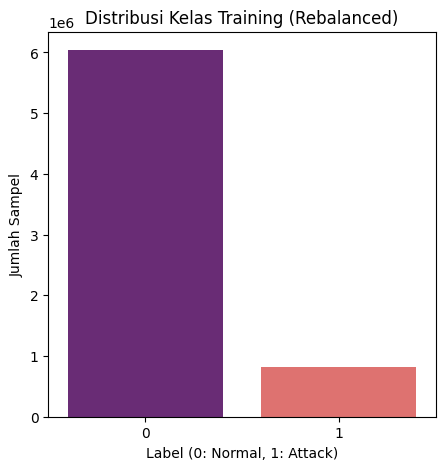

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 5))
sns.countplot(x=y_train, palette='magma')
plt.title('Distribusi Kelas Training (Rebalanced)')
plt.ylabel('Jumlah Sampel')
plt.xlabel('Label (0: Normal, 1: Attack)')
plt.show()


In [10]:
from minisom import MiniSom

# Bersihkan NaN/Inf jika ada sisa
X_train = np.nan_to_num(X_train, nan=0.0, posinf=1.0, neginf=-1.0)
X_train = X_train.astype('float32')

# Subset untuk mempercepat training (opsional, sesuaikan dengan RAM)
sample_size = min(1000000, len(X_train))
X_train_sub = X_train[:sample_size]
y_train_sub = y_train[:sample_size]

som = MiniSom(x=15, y=15, input_len=X_train.shape[1], 
              sigma=1.5, learning_rate=0.5, random_seed=42)

som.random_weights_init(X_train_sub)
som.train_random(X_train_sub, sample_size, verbose=True)



 [ 1000000 / 1000000 ] 100% - 0:00:00 left 
 quantization error: 0.27645888173419403


In [11]:
from sklearn.metrics import classification_report, confusion_matrix

label_map = som.labels_map(X_train_sub, y_train_sub)
winner_labels = np.zeros((15, 15)) # Set default semua neuron ke 0 (Normal)

# Menerapkan threshold kepercayaan untuk mengurangi False Positive
CONFIDENCE_THRESHOLD = 0.75 

for position, labels in label_map.items():
    total_samples = sum(labels.values())
    most_common = labels.most_common(1)[0]
    
    # Jika dominan kelas Attack (1), cek apakah rasionya melebihi threshold
    if most_common[0] == 1:
        confidence = most_common[1] / total_samples
        if confidence >= CONFIDENCE_THRESHOLD:
            winner_labels[position] = 1
        else:
            # Jika ambigu (misal 55% attack, 45% normal), paksa jadi normal 
            # untuk menghindari false positive pada jaringan nyata
            winner_labels[position] = 0
    else:
        winner_labels[position] = 0

unique, counts = np.unique(winner_labels, return_counts=True)
print("\nDistribusi label pada neuron SOM:", dict(zip(unique, counts)))



Distribusi label pada neuron SOM: {0.0: 211, 1.0: 14}



Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    440549
           1       0.98      0.73      0.84     59451

    accuracy                           0.97    500000
   macro avg       0.97      0.86      0.91    500000
weighted avg       0.97      0.97      0.96    500000



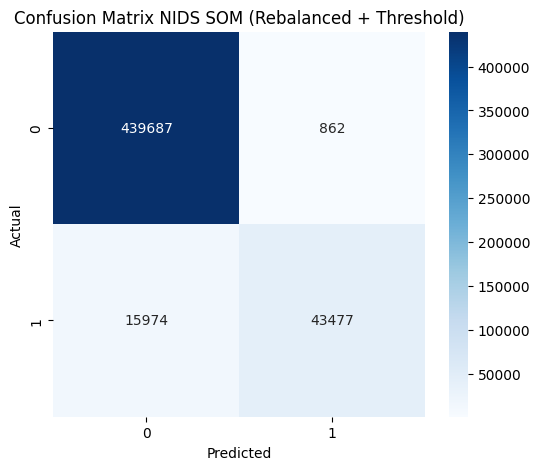

In [12]:
test_size = min(500000, len(X_test))
X_test_sub = X_test[:test_size]
y_test_sub = y_test[:test_size]

y_pred = []
for x in X_test_sub: 
    winner = som.winner(x)
    y_pred.append(winner_labels[winner])

print("\nClassification Report:")
print(classification_report(y_test_sub, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test_sub, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix NIDS SOM (Rebalanced + Threshold)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [13]:
import joblib

export_data = {
    'model': som,
    'scaler': scaler,
    'winner_labels': winner_labels
}

model_path = '../model/nids_som_rebalanced.joblib'
joblib.dump(export_data, model_path)
print(f"Model berhasil disimpan di: {model_path}")

Model berhasil disimpan di: ../model/nids_som_rebalanced.joblib
